# Model Evaluation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error)
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from data_processing.model import (X_train, y_train, X_test, y_test, pipeline)

## 1. Hyperparameter Tuning

In [ ]:
def cross_val():
    """
    One-time hyperparameter tuning performed during model development
    using the preprocessed training data.

    Uses GridSearchCV with 5-fold cross-validation and reports the
    best hyperparameters and mean validation R2 score.

    Retained for documentation purposes only. This portion is not executed 
    as part of the final model training workflow.
    """

    param_grid = {
        'max_depth': [5, 10, 15, None],
        'n_estimators': [100, 200],
        'min_samples_leaf': [2, 4],
        'min_samples_split': [5, 10]
    }

    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring='r2',
        cv=5
    )

    grid_search.fit(X_train, y_train)
    best_estimator_number = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    print("Best parameters:", best_params)
    print("Best R2 score:", best_score)

This best set of hyperparameters obtained from 5-fold cross validation is the set of hyperparameters used in the model (as shown below).

```python
regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=4,
    min_samples_split=5,
    random_state=42
)

## 2. Test Set Performance Metrics

In [ ]:
y_predicted = pipeline.predict(X_test)

r2 = pipeline.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_predicted)
rmse = np.sqrt(mean_squared_error(y_test, y_predicted))

print(f"r2: {r2:.4f}")
print(f"mae: {mae:.4f}")
print(f"rmse: {rmse:.4f}")

multiplicative_error = np.exp(mae)
print(f"multiplicative error factor: {multiplicative_error:.4f}x")

```markdown
r2: 0.5551
mae: 0.4084
rmse: 0.8815
multiplicative error factor: 1.5044x
```
---

**Interpretation of Metrics**

The final Random Forest model achieved an R2 of 0.56 on the held-out test set, indicating that approximately 56% of the variance in log-transformed stream counts is explained by the selected audio features, playlist exposure and song release timing.

As stream counts are log-normalised, the MAE of 0.41 log units corresponds to a mean multiplicative error factor of approximately 1.50x. This means the predicted stream counts are typically around a factor of 1.50 (exp(0.4084) ≈ 1.50) away from the true stream count when converted back to the original scale.

The RMSE of 0.88 log units is higher than the MAE, indicating that while most prediction errors are relatively moderate, some observations have substantially larger prediction errors.

## 3. Analysis of Residuals

### 3.1 Residuals vs Predictions (log space)

In [ ]:
resids = y_test - y_predicted

plt.scatter(y_predicted, resids, alpha=0.5)
plt.axhline(0, color="red")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

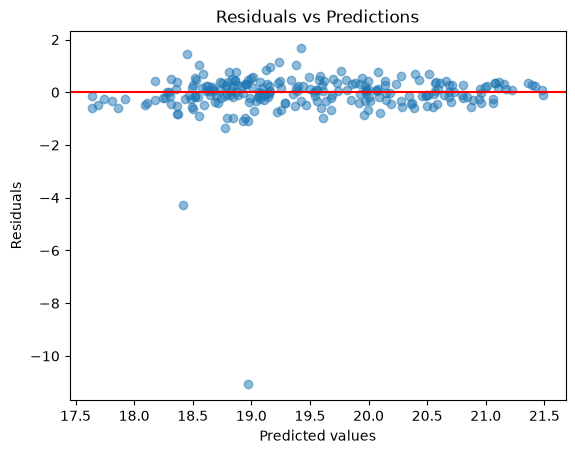

**Interpretation of Residual Analysis**

Residuals are generally concentrated around 0 on the log scale, with most falling approximately between -1.5 and +2. This indicates that for most observations, prediction errors are reasonably centered around the model's predictions.

A very small number of observations show substantially larger negative residuals, indicating that the model occasionally overestimates stream counts by a large margin. As RMSE penalises large errors more heavily than MAE, these outliers help to explain why RMSE is considerably higher than MAE here.

### 3.2 Predicted vs Actual Stream Counts (raw scale)

In [ ]:
# Transform to raw scale
y_test_raw = np.exp(y_test) - 1
y_predicted_raw = np.exp(y_predicted) - 1

plt.figure(figsize=(6,6))
plt.scatter(y_test_raw, y_predicted_raw, alpha=0.3, s=15)

min_value = max(y_test_raw.min(), y_predicted_raw.min())
max_value = max(y_test_raw.max(), y_predicted_raw.max())
plt.plot([min_value, max_value], [min_value, max_value])    # Diagonal line y=x representing perfect prediction
plt.xscale("log")       # Use log-log scale
plt.yscale("log")
plt.xlim(1e6, 3e9)
plt.ylim(1e6, 3e9)
plt.xlabel("Actual Stream Count")
plt.ylabel("Predicted Stream Count")
plt.title("Predicted vs Actual Spotify Stream Counts (Raw Scale)")
plt.tight_layout()
plt.show()

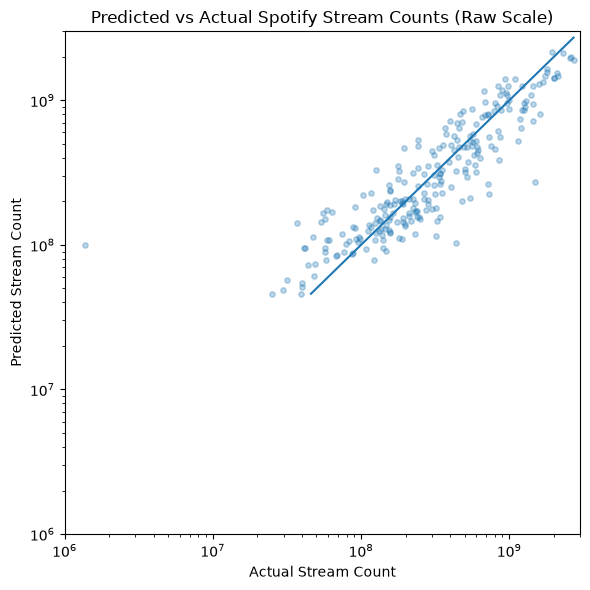

*Axes are restricted to the range containing the majority of observations.*

**Interpretation of Predicted vs Actual Plot**

The predicted vs actual plot in raw stream counts (log-log scale) shows partial alignment with the diagnoal line, indicating that the model preserves some relative ordering among moderately popular songs. However, the model's predictions are increasingly compressed at the upper tail, which causes the most highly streamed songs to be underestimated and absolute error to widen.

Given the optimisation in log space and how playlist exposure dominates as a predictive feature, this behaviour is expected and helps to explain how *absolute* errors are higher for songs in the highest popularity quartile. Overall, while the model performs reasonably in distinguishing low-to-mid popularity songs, it under-differentiates among extremely popular songs.

## 4. Error Analysis by Stream Count Quantiles (Error Stratification by Popularity Range)

To examine whether prediction performance differs across popularity ranges, test observations were divided into quartiles according to their actual stream counts. 

Two complementary error measures were used:
- raw-scale relative error, which highlights extreme proportional prediction failures, and
- median absolute log error, which provides a more robust measure of the model's typical prediction performance.

### 4.1 Raw-scale Relative Error

In [ ]:
# Convert predictions and targets back to raw stream counts
y_test_raw = np.exp(y_test)
y_pred_raw = np.exp(y_predicted)

relative_error_raw = ((np.abs(y_test_raw - y_pred_raw) / y_test_raw))

df_error = pd.DataFrame({
    "y_actual": y_test_raw,
    "y_predicted": y_pred_raw,
    "absolute_log_error": np.abs(y_test - y_predicted)
})

# Raw-scale relative error
df_error["relative_error"] = (
    np.abs(df_error["y_actual"] - df_error["y_predicted"])
    / df_error["y_actual"]
)

# Divide songs into stream count quartiles
df_error["category"] = pd.qcut(
    df_error["y_actual"], 
    q=4, 
    labels=[
        "low-streams", "mid-low streams", "mid-high streams", "popular"
    ]
)

# Mean relative error by quartile
mean_relative_error = (
    df_error.groupby("category", observed=False)["relative_error"].mean()
)

mean_relative_error

```markdown
category
low-streams         1035.309418
mid-low streams        0.308450
mid-high streams       0.317114
popular                0.284246
Name: relative_error, dtype: float64
```

In [ ]:
# Inspect observations with the largest proportional errors
df_error.nlargest(
    3, "relative_error"
)[["y_actual", "y_predicted", "relative_error"]]

```markdown
	y_actual	y_predicted	relative_error
109	2762.0	        1.741392e+08    63047.236955
342	1365184.0	9.922900e+07	71.685441
680	37091576.0	1.424140e+08	2.839525
```

**Interpretation of Raw-scale Relative Error**

Mean relative error varies considerably across stream count quantiles. In particular, the low-streams group has an exceptionally large mean relative error because it contains an extreme observation with only 2762 actual streams that was very substantially overpredicted by the model.

This demonstrates an important limitation of percentage-based error measures. When the actual target value is very small, even one large overprediction can produce an extremely large relative error, which would dominate the group's mean relative error. Therefore, mean relative error is not an appropriate measure of typical model performance across the quantiles.

The observation is retained because its stream count is present in the original dataset and there is no evidence to conclude that it is erroneous.

### 4.2 Median Absolute Log Error

In [ ]:
median_log_error = (
    df_error.groupby("category", observed=False)["absolute_log_error"].median()
)

median_error_factor = np.exp(median_log_error)

log_error_summary = pd.DataFrame({
    "median_absolute_log_error": median_log_error,
    "multiplicative_error_factor": median_error_factor
})

log_error_summary

```markdown
                  median_absolute_log_error	multiplicative_error_factor
category		
low-streams	         0.329227                    	1.389893
mid-low streams	         0.256300	                1.292140
mid-high streams	 0.315048	                1.370325
popular	                 0.278109	                1.320630
````

**Interpretation of Median Absolute Log Error**

As mean raw-scale relative error is highly sensitive to unusually small actual stream counts, median absolute log error is used as a complementary measure of typical prediction performance. The median is less sensitive to outliers, and therefore less affected by isolated extreme prediction failures, while the log scale is consistent with the transformed target during model training.

Exponentiating the median absolute log error gives an approximate median multiplicative error factor, allowing the results to be interpreted more intuitively on the original scale of stream counts.

From the summary above, median absolute log error and multiplicative error factor are fairly similar across all four quartiles, ranging from approximately 1.29x to 1.39x. This suggests that the typical prediction accuracy is broadly comparable across popularity ranges despite the presence of an extreme prediction failure in the low-stream group. 

### 4.3 Raw-scale Absolute Error

In [ ]:
df_error["absolute_error_raw"] = np.abs(df_error["y_actual"] - df_error["y_predicted"])

df_error["absolute_error_millions"] = df_error["absolute_error_raw"] / 1e6

df_error["category"] = pd.qcut(
    df_error["y_actual"],
    q=4,
    labels=["low streams", "mid-low streams", "mid-high streams", "popular"]
)

df_error.boxplot(
    column="absolute_error_millions",
    medianprops=dict(color="green"), 
    by="category",
    grid=False
)

plt.xlabel("Popularity Group")
plt.ylabel("Absolute Error (millions of streams)")
plt.title("Raw-scale Absolute Error by Song Popularity Quartile")
plt.suptitle("")        # Remove default title
plt.tight_layout()
plt.show()

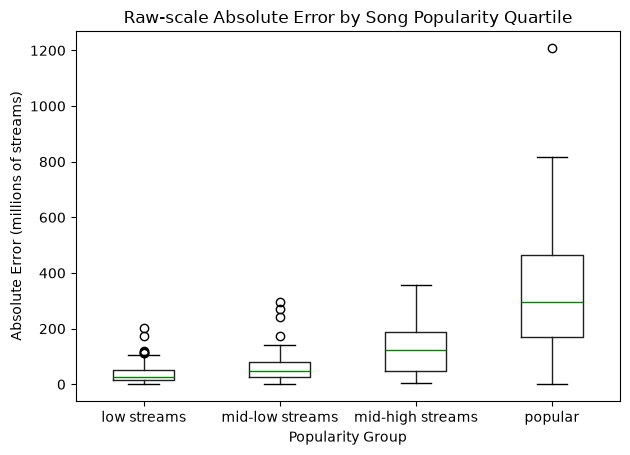

**Interpretation of Boxplot**

Absolute prediction errors generally increase across the stream count quartiles. Songs in the popular quartile show the largest median absolute error and the widest spread of errors, indicating that predictions for highly streamed songs can differ from their actual values by substantially larger numbers of streams.

This pattern is expected for a metric like absolute error, which is scale dependent. Highly popular songs have much larger actual stream counts, so similar proportional prediction errors can correspond to much larger differences in raw stream counts.

When considered alongside the median absolute log error analysis above, the results suggest that typical multiplicative prediction accuracy is relatively similar across popularity ranges, even though the magnitude of errors in raw stream counts increase considerably for more popular songs.

## 5. Ablation Study: Effect of Removing Playlist Exposure on Model Performance

To examine the predictive importance of a song's Spotify playlist exposure, the model was retrained after removing the `in_spotify_playlists` feature, which represents the number of Spotify playlists containing a song.

**Results of Study**

<table>
    <thead>
        <th>Metric</th>
        <th>With Playlist Exposure</th>
        <th>Without Playlist Exposure</th>
    </thead>
    <tbody>
        <tr>
            <td>R2</td>
            <td>0.5551</td>
            <td>0.3668</td>
        </tr>
        <tr>
            <td>MAE</td>
            <td>0.4084</td>
            <td>0.6151</td>
        </tr>
        <tr>
            <td>RMSE</td>
            <td>0.8815</td>
            <td>1.0516</td>
        </tr>
    </tbody>
</table>

**Interpretation of Results**

Removing playlist exposure reduced R2 by 0.1883, which is approximately a 34% relative reduction in the variance of Spotify stream counts explained by the model, compared to the original model. 

Since the target variable is log-transformed, the increase in MAE from 0.4084 to 0.6151 roughly corresponds to an increase in the typical multiplicative error from 1.50x to 1.85x in raw stream counts (exp(0.4084) ≈ 1.50, exp(0.6151) ≈ 1.85). 

RMSE also increased from 0.8815 to 1.0516, indicating that the larger prediction errors became more severe after playlist exposure was removed.

Together, these results suggest that playlist exposure provides substantial predictive information about Spotify stream counts. While audio features and release timing retain some predictive signal, less of the variance in stream counts can be explained without playlist exposure information. 

Therefore, this experiment highlights an important limitation of predicting a song's streaming success from intrinsic song characteristics and release metadata alone: 
- **Audio chracteristics and release metadata alone cannot fully explain a song's observed streaming success on Spotify.**

## 6. Analysis of Features (Feature Importance)

In [ ]:
# Showing feature schema for transparency (raw data not included)
print(X_test.info())

```
<class 'pandas.DataFrame'>
Index: 245 entries, 196 to 404
Data columns (total 31 columns):
 #    Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   released_year         245 non-null    int64  
 1   in_spotify_playlists  245 non-null    int64  
 2   mode                  245 non-null    int64  
 3   key_A#                245 non-null    float64
 4   key_B                 245 non-null    float64
 5   key_C#                245 non-null    float64
 6   key_D                 245 non-null    float64
 7   key_D#                245 non-null    float64
 8   key_E                 245 non-null    float64
 9   key_F                 245 non-null    float64
 10  key_F#                245 non-null    float64
 11  key_G                 245 non-null    float64
 12  key_G#                245 non-null    float64
 13  released_month_2      245 non-null    float64
 14  released_month_3      245 non-null    float64
 15  released_month_4      245 non-null    float64
 16  released_month_5      245 non-null    float64
 17  released_month_6      245 non-null    float64
 18  released_month_7      245 non-null    float64
 19  released_month_8      245 non-null    float64
 20  released_month_9      245 non-null    float64
 21  released_month_10     245 non-null    float64
 22  released_month_11     245 non-null    float64
 23  released_month_12     245 non-null    float64
 24  bpm                   245 non-null    float64
 25  danceability_%        245 non-null    float64
 26  valence_%             245 non-null    float64
 27  energy_%              245 non-null    float64
 28  speechiness_%_log     245 non-null    float64
 29  liveness_%_log        245 non-null    float64
 30  acousticness_%_log    245 non-null    float64
dtypes: float64(28), int64(3)
memory usage: 61.2 KB
None
```

In [ ]:
def grouped_permutation_importance(model, X, y, feature_prefix, n_repeats=20, random_state=42):
    """
    Permutes all one-hot columns sharing the same prefix together to
    estimate the importance of the original categorical feature.
    """
    
    cols = [col for col in X.columns if col.startswith(feature_prefix)]
    baseline = model.score(X, y)

    rng = np.random.default_rng(random_state)
    drops = []      # Stores how much R2 decreases after each random permutation

    for _ in range(n_repeats):
        X_permuted = X.copy()
        shuffled_index = rng.permutation(len(X))
        # Shuffle together all grouped columns to break their relationship with the target
        X_permuted[cols] = X.iloc[shuffled_index][cols].values
        decrease_in_r2 = baseline - model.score(X_permuted, y)
        drops.append(decrease_in_r2)

    return np.mean(drops)


# Compute grouped permutation importance for release month and key
released_month_importance = grouped_permutation_importance(
    model=pipeline,
    X=X_test,
    y=y_test,
    feature_prefix="released_month_",
    n_repeats=20,
    random_state=42
)
key_importance = grouped_permutation_importance(
    model=pipeline,
    X=X_test,
    y=y_test,
    feature_prefix="key_",
    n_repeats=20,
    random_state=42
)

Dummy columns for a categorical feature are simultaneously permuted to measure the feature's overall contribution to the model by estimating the feature's effect as if it was removed.

In [ ]:
result = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": result.importances_mean,
    })
    .sort_values(by="importance_mean", ascending=False)
    .head(15)
)

# Remove one-hot month and key columns
importance_df = importance_df.loc[importance_df["feature"].str.startswith("released_month_") == False]
importance_df = importance_df.loc[importance_df["feature"].str.startswith("key_") == False]

# Append the grouped importance for released_month and key
importance_df = pd.concat([
    importance_df,
    pd.DataFrame({
        "feature": ["released_month", "key"],
        "importance_mean": [released_month_importance, key_importance]
    })
], ignore_index=True)

# Sort for plotting
importance_df = importance_df.sort_values(by="importance_mean", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"],
    importance_df["importance_mean"],
)
plt.xlabel("Decrease in R2 After Permutation")
plt.title("Permutation Feature Importance (Grouped Months and Keys)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

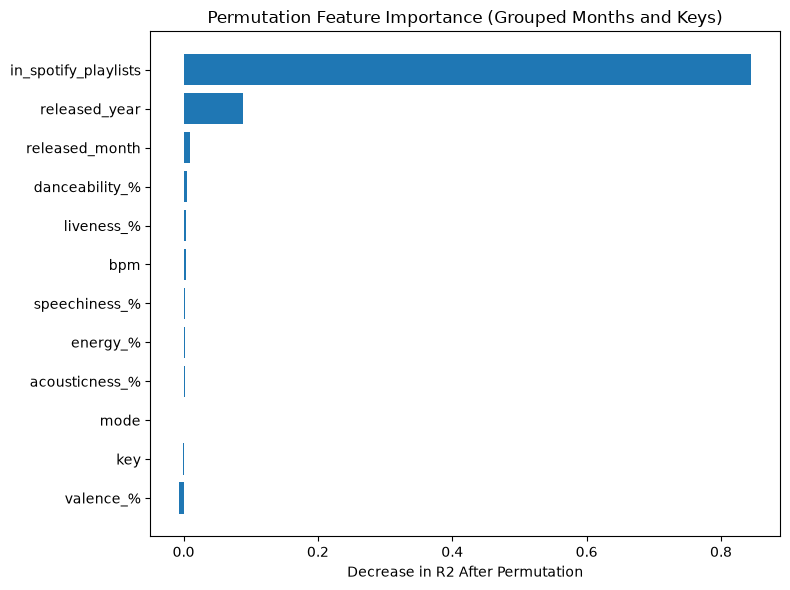

*Note: As permuting a highly informative feature can lead to negative R2 values (which indicate worse performance than predicting the mean), permutation importance can result in decreases in R2 that are larger than the model's original R2.*

**Permutation Feature Importance Analysis**

The permutation importance results show that `in_spotify_playlists` is the most influential feature. Permuting this variable leads to a substantial drop in R2, indicating that playlist exposure plays a dominant role in the model's predictive performance.

`released_year` demonstrates a smaller but still meaningful contribution to the model. This suggests that temporal factors, like the streaming platform's growth over time, do play a role in explaining predicted stream counts.

In contrast, grouped variables (released month and key of song), as well as audio characteristics, contribute minimally to the model's performance once playlist exposure is taken into account.

These findings closely align with the ablation study's results, which showed that removing data on playlist exposure caused a sharp decline in model performance. Together, these analyses confirm that the model primarily relies on playlist exposure data, rather than intrinsic audio characteristics of a song. This dependence suggests that the model is better interpreted as a predictor of a song's realised popularity after exposure, rather than as a tool for discovering high-potential songs before they are included in playlists.